# Notebook de Análisis Exploratorio de Datos (EDA) y Simulación Monte Carlo
> **No Country Project - Épica 2** | Análisis estadístico, campanas de Gauss y estimación estocástica de Capacidad Varada (Stranded Capacity).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from monte_carlo_simulation import run_monte_carlo_simulation, COOLING_STATS

# Configuración de estilo visual para gráficos premium
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

print("[OK] Entorno de analisis cargado correctamente.")


[OK] Entorno de analisis cargado correctamente.


---
## 1. Carga del Dataset y Benchmarks Curados
Cargamos los archivos `benchmarks_reales.csv` y el dataset sintético de 5,000 registros `dataset_5000_datacenters.csv`.


In [2]:
# Carga de datos
benchmarks_df = pd.read_csv('benchmarks_reales.csv')
dataset_df = pd.read_csv('dataset_5000_datacenters.csv')

print("--- Benchmarks Reales Curados ---")
display(benchmarks_df)

print("--- Resumen Estadistico del Dataset Sintetico (5,000 registros) ---")
display(dataset_df.describe().T[['mean', 'std', 'min', '50%', 'max']])


--- Benchmarks Reales Curados ---


,fuente,ano,tecnologia_cooling,pue_ref_min,pue_ref_mid,pue_ref_max,stranded_pct_min,stranded_pct_mid,stranded_pct_max,tarifa_electrica_usd_kwh,colocation_usd_kw_mes,capex_usd_per_mw,ccf_typical,ahorro_energia_nodo_pct
0,Microsoft GFS (Sankar & Vaid),2010,air-cooled,1.50,1.58,1.65,12.0,12.5,13.0,0.12,184.0,11000000.0,3.9,0.0
1,Supermicro Liquid Cooling Report,2025,liquid-cooled,1.05,1.08,1.12,2.0,3.5,5.0,0.12,184.0,17500000.0,1.2,16.0
2,Industry & EIA Hybrid Benchmarks,2026,hybrid,1.20,1.25,1.30,8.0,9.0,10.0,0.12,184.0,13500000.0,1.8,8.0
3,Uptime Institute Global Survey,2024,air-cooled,1.52,1.58,1.68,11.5,12.5,13.5,0.12,184.0,11000000.0,3.9,0.0


--- Resumen Estadistico del Dataset Sintetico (5,000 registros) ---


,mean,std,min,50%,max
facility_mw,2.265182e+01,2.113670e+01,1.230,1.662500e+01,2.500000e+02
utilization_pct,7.197632e+01,1.173629e+01,24.900,7.210000e+01,9.800000e+01
electricity_rate_usd_kwh,1.203383e-01,2.004398e-02,0.060,1.203000e-01,2.096000e-01
colocation_usd_kw_month,1.838666e+02,1.492241e+01,126.150,1.839200e+02,2.381700e+02
pue_realized,1.410928e+00,2.039025e-01,1.020,1.523000e+00,1.756000e+00
capex_usd_per_mw,1.267590e+07,2.355073e+06,9126857.440,1.160387e+07,1.986284e+07
stranded_capacity_pct,1.019577e+01,3.224432e+00,2.000,1.212000e+01,1.710000e+01
stranded_capacity_mw,2.310827e+00,2.349906e+00,0.026,1.633500e+00,3.210000e+01
loss_floor_usd_annual,9.730848e+06,9.750880e+06,132313.390,6.883299e+06,1.287503e+08
loss_ceiling_usd_annual,5.096698e+06,5.219578e+06,59891.520,3.599017e+06,7.269880e+07


---
## 2. Gráficos de Distribución (Campanas de Gauss)
Visualización de la densidad de probabilidad para PUE (segmentado por Cooling), Tarifa Eléctrica y Porcentaje de Utilización.


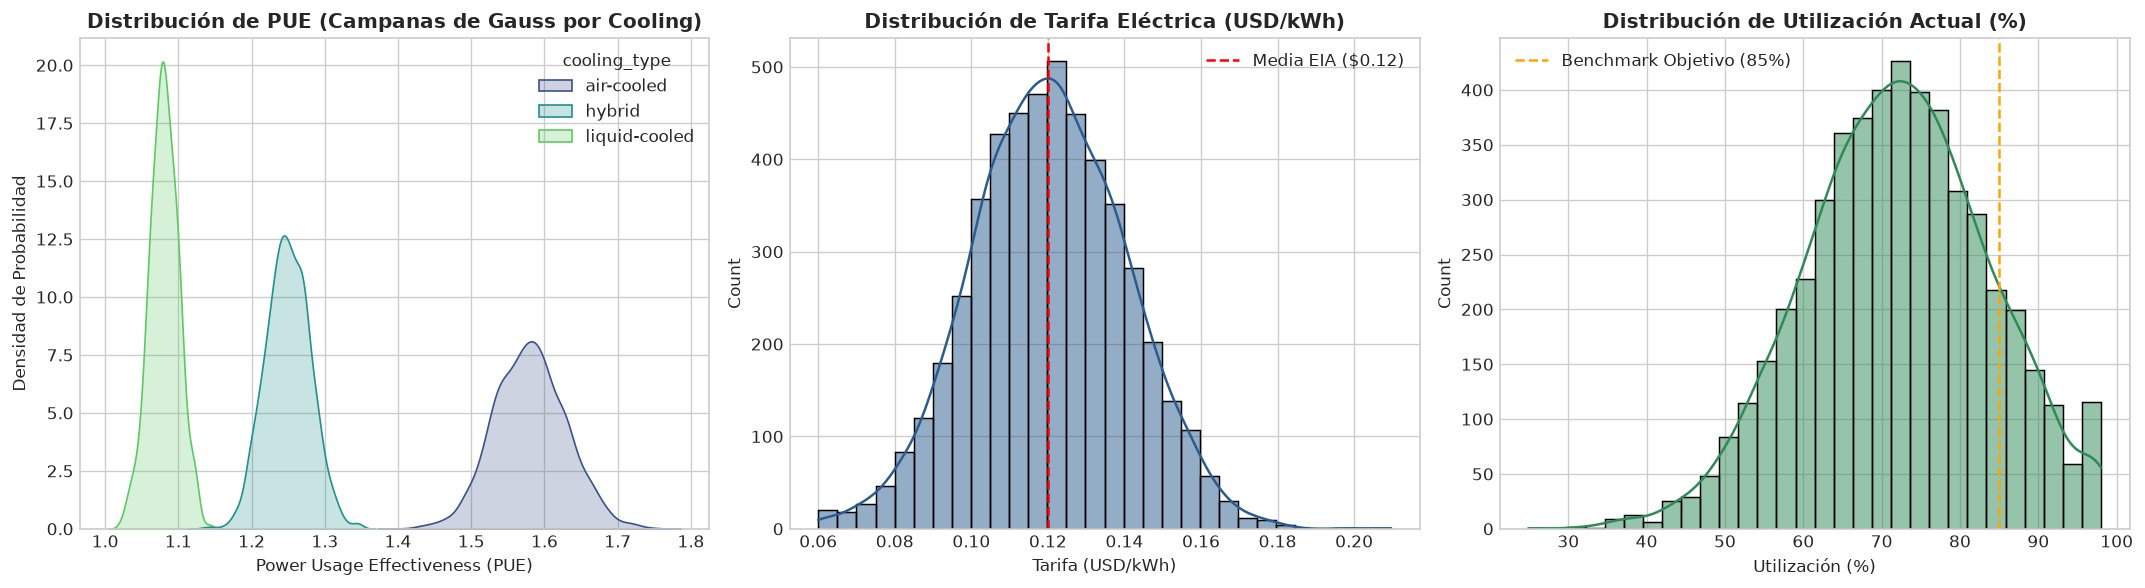

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución de PUE por Tipo de Enfriamiento
sns.kdeplot(data=dataset_df, x='pue_realized', hue='cooling_type', fill=True, common_norm=False, palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de PUE (Campanas de Gauss por Cooling)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Power Usage Effectiveness (PUE)')
axes[0].set_ylabel('Densidad de Probabilidad')

# 2. Distribución de Tarifas Eléctricas ($/kWh)
sns.histplot(dataset_df['electricity_rate_usd_kwh'], kde=True, color='#2b5c8f', bins=30, ax=axes[1])
axes[1].axvline(0.12, color='red', linestyle='--', label='Media EIA ($0.12)')
axes[1].set_title('Distribución de Tarifa Eléctrica (USD/kWh)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tarifa (USD/kWh)')
axes[1].legend()

# 3. Distribución de Utilización (%)
sns.histplot(dataset_df['utilization_pct'], kde=True, color='#2e8b57', bins=30, ax=axes[2])
axes[2].axvline(85.0, color='orange', linestyle='--', label='Benchmark Objetivo (85%)')
axes[2].set_title('Distribución de Utilización Actual (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Utilización (%)')
axes[2].legend()

plt.tight_layout()
plt.show()


---
## 3. Simulación de Monte Carlo (Percentiles P10, P50, P90)
Ejecución del motor de Monte Carlo con 10,000 iteraciones estocásticas para una instalación típica de **20 MW** con enfriamiento tradicional de aire (`air-cooled`).


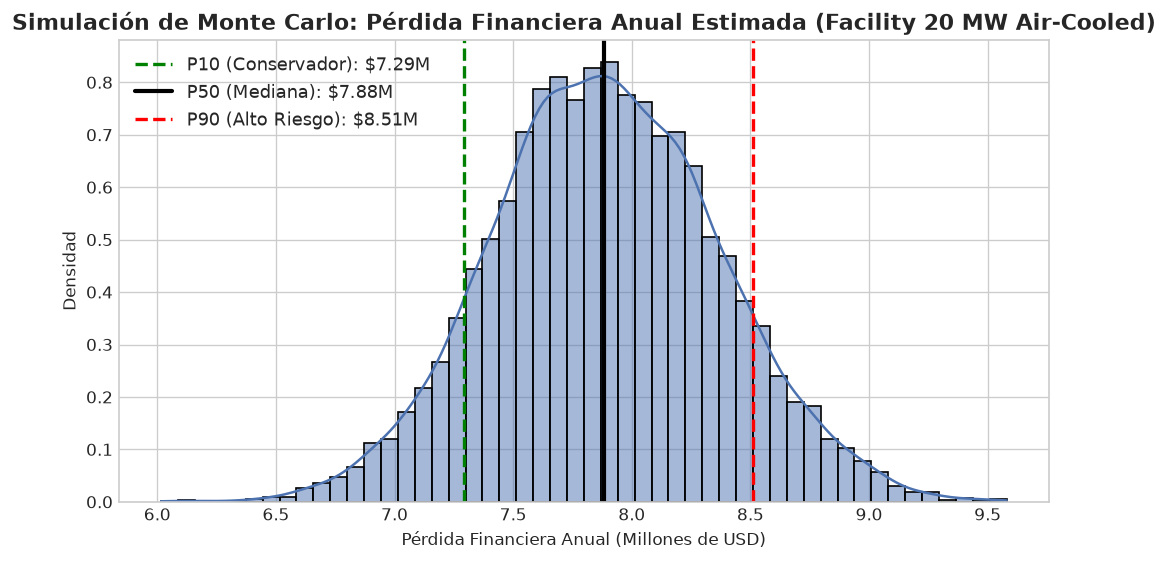

--- Percentiles de Confianza ---
   - P10: $7,291,729.02 USD/año
   - P50: $7,882,744.05 USD/año
   - P90: $8,509,222.17 USD/año


In [4]:
# Ejecutar simulación de Monte Carlo
sim_res = run_monte_carlo_simulation(facility_mw=20.0, utilization_pct=75.0, cooling_type='air-cooled', num_simulations=10000)

p10 = sim_res['percentiles']['loss_mid_usd']['p10']
p50 = sim_res['percentiles']['loss_mid_usd']['p50']
p90 = sim_res['percentiles']['loss_mid_usd']['p90']
raw_losses = sim_res['raw_simulations']['loss_mid_usd'] / 1e6  # En millones de USD

plt.figure(figsize=(10, 5))
sns.histplot(raw_losses, kde=True, color='#4c72b0', bins=50, stat='density')

plt.axvline(p10 / 1e6, color='green', linestyle='--', linewidth=2, label=f'P10 (Conservador): ${p10/1e6:.2f}M')
plt.axvline(p50 / 1e6, color='black', linestyle='-', linewidth=2.5, label=f'P50 (Mediana): ${p50/1e6:.2f}M')
plt.axvline(p90 / 1e6, color='red', linestyle='--', linewidth=2, label=f'P90 (Alto Riesgo): ${p90/1e6:.2f}M')

plt.title('Simulación de Monte Carlo: Pérdida Financiera Anual Estimada (Facility 20 MW Air-Cooled)', fontsize=13, fontweight='bold')
plt.xlabel('Pérdida Financiera Anual (Millones de USD)')
plt.ylabel('Densidad')
plt.legend(fontsize=11)
plt.show()

print(f"--- Percentiles de Confianza ---")
print(f"   - P10: ${p10:,.2f} USD/año")
print(f"   - P50: ${p50:,.2f} USD/año")
print(f"   - P90: ${p90:,.2f} USD/año")


---
## 4. Comparativa de Pérdidas y ROI por Tecnología de Cooling
Análisis del impacto financiero y tiempo de retorno de inversión (ROI) según la tecnología desplegada.


C:\Users\josec\AppData\Local\Temp\ipykernel_21276\1449704956.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_df, x='cooling_type', y='loss_mid_usd_annual', palette='Blues_d', ax=axes[0])
C:\Users\josec\AppData\Local\Temp\ipykernel_21276\1449704956.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset_df, x='cooling_type', y='roi_months', palette='Greens_d', ax=axes[1])


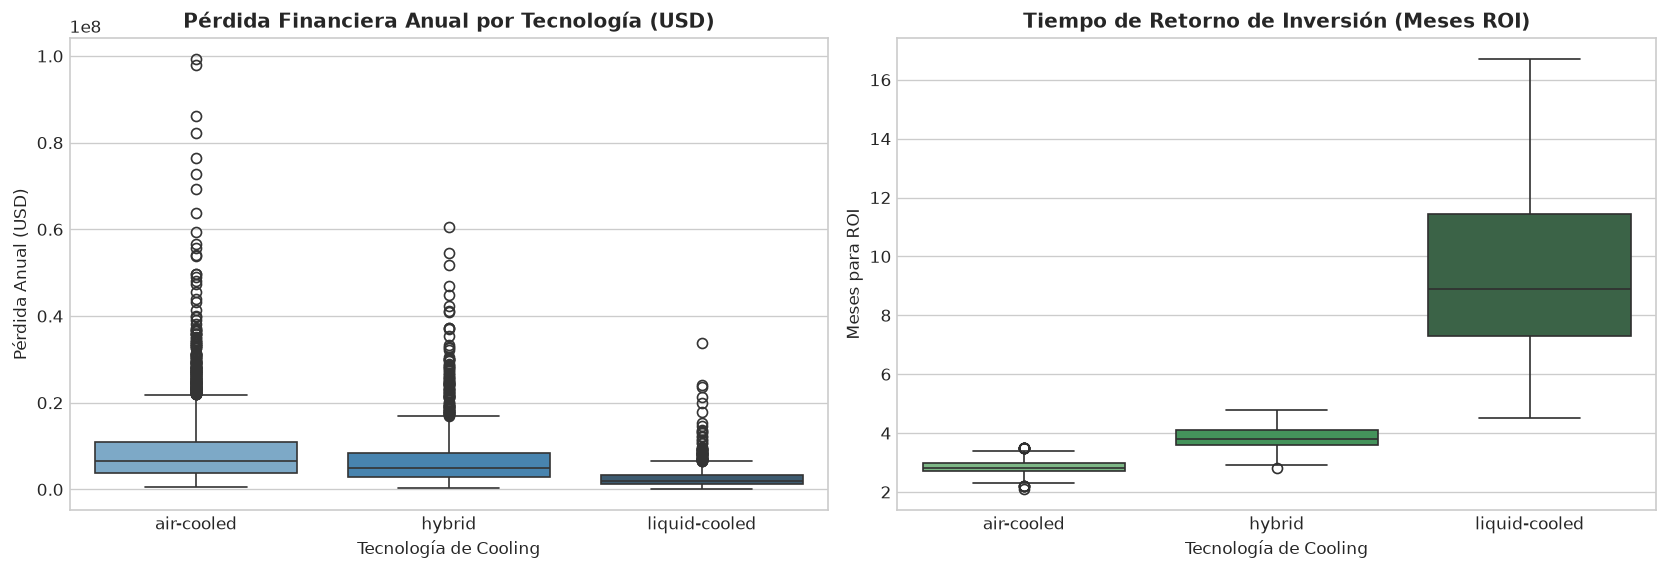

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de Pérdida Financiera Anual Mid (USD)
sns.boxplot(data=dataset_df, x='cooling_type', y='loss_mid_usd_annual', palette='Blues_d', ax=axes[0])
axes[0].set_title('Pérdida Financiera Anual por Tecnología (USD)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tecnología de Cooling')
axes[0].set_ylabel('Pérdida Anual (USD)')

# Boxplot de Meses de ROI de Remediación
sns.boxplot(data=dataset_df, x='cooling_type', y='roi_months', palette='Greens_d', ax=axes[1])
axes[1].set_title('Tiempo de Retorno de Inversión (Meses ROI)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tecnología de Cooling')
axes[1].set_ylabel('Meses para ROI')

plt.tight_layout()
plt.show()


---
## 5. Matriz de Correlación
Identificación de relaciones lineales entre variables de entrada y métricas de desperdicio/pérdida.


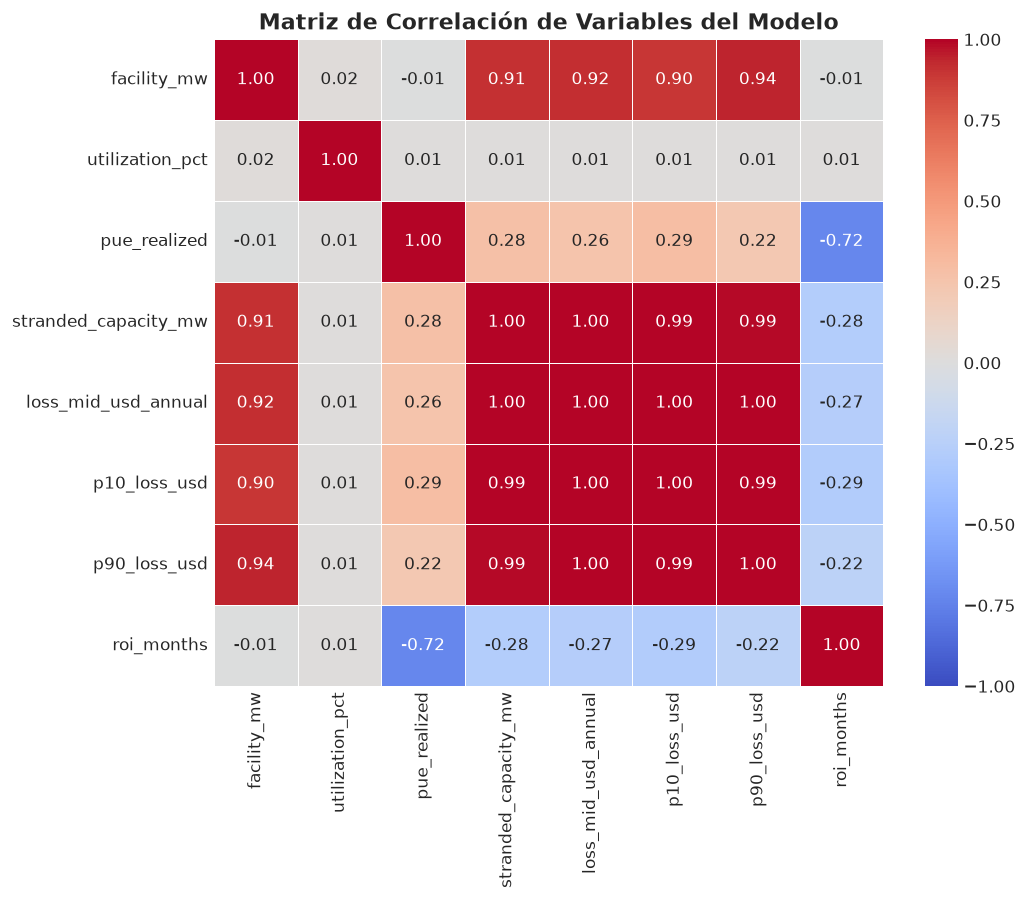

In [6]:
numeric_cols = ['facility_mw', 'utilization_pct', 'pue_realized', 'stranded_capacity_mw', 'loss_mid_usd_annual', 'p10_loss_usd', 'p90_loss_usd', 'roi_months']
corr_matrix = dataset_df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Variables del Modelo', fontsize=13, fontweight='bold')
plt.show()
